<a href="https://colab.research.google.com/github/Manireddy69/Data-science/blob/main/house_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import necessay libraries
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [5]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
train.shape

(1460, 81)

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [10]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [27]:
train['LotFrontage'] = train['LotFrontage'].fillna(train['LotFrontage'].median())

In [28]:
train.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [31]:
train.select_dtypes(include = "object").columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [34]:
#converting into one-hot encoding
train = pd.get_dummies(train, drop_first = True)

In [35]:
X = train.drop("SalePrice", axis = 1)
y = train["SalePrice"]

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size= 0.2, random_state= 42)


In [40]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# Impute remaining numerical NaNs in X_train and X_valid
# using the median from X_train to prevent data leakage
if 'MasVnrArea' in X_train.columns:
    masvnrarea_median = X_train['MasVnrArea'].median()
    X_train['MasVnrArea'] = X_train['MasVnrArea'].fillna(masvnrarea_median)
    X_valid['MasVnrArea'] = X_valid['MasVnrArea'].fillna(masvnrarea_median)

if 'GarageYrBlt' in X_train.columns:
    garageyrblt_median = X_train['GarageYrBlt'].median()
    X_train['GarageYrBlt'] = X_train['GarageYrBlt'].fillna(garageyrblt_median)
    X_valid['GarageYrBlt'] = X_valid['GarageYrBlt'].fillna(garageyrblt_median)

model.fit(X_train, y_train)

LinearRegression()

In [44]:
#now with test data
test= pd.read_csv('test.csv')
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [45]:
test.shape

(1459, 80)

In [48]:
test.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,4
LotFrontage,227
LotArea,0
...,...
MiscVal,0
MoSold,0
YrSold,0
SaleType,1


In [53]:
# Create a temporary DataFrame to get the original 'MSZoning' mode and 'LotFrontage' median
# from the training data. This is necessary because the 'train' DataFrame currently in memory
# has already been one-hot encoded.
original_train_data_for_imputation = pd.read_csv("train.csv")

test['LotFrontage'] = test['LotFrontage'].fillna(original_train_data_for_imputation['LotFrontage'].median())
test['MSZoning'] = test['MSZoning'].fillna(original_train_data_for_imputation['MSZoning'].mode()[0])

In [54]:
test = pd.get_dummies(test, drop_first=True)

In [55]:
test = test.reindex(columns=X_train.columns,fill_value= 0)

In [57]:
# Iterate through each column in the 'test' DataFrame and impute any remaining numerical NaNs.
# This ensures consistency with the training data and handles all numerical missing values.
for column in test.columns:
    if test[column].isnull().any():
        # Check if the column is numerical (e.g., float, int)
        if pd.api.types.is_numeric_dtype(test[column]):
            # Impute with the median from the corresponding X_train column
            # This prevents data leakage and ensures consistency in data preprocessing.
            if column in X_train.columns:
                median_val_from_X_train = X_train[column].median()
                test[column] = test[column].fillna(median_val_from_X_train)
            else:
                # If a column exists in test but not X_train (shouldn't happen after reindex), handle as needed.
                # For now, we'll just fill with 0 or a placeholder if it's new and has NaNs.
                test[column] = test[column].fillna(0)

predictions = model.predict(test)

In [59]:
from sklearn.metrics import mean_absolute_error

# Make predictions on the validation set
valid_predictions = model.predict(X_valid)

# Calculate MAE using y_valid and predictions on X_valid
mae = mean_absolute_error(y_valid, valid_predictions)
print(f"Mean Absolute Error on Validation Set: {mae}")

Mean Absolute Error on Validation Set: 20498.50715690966


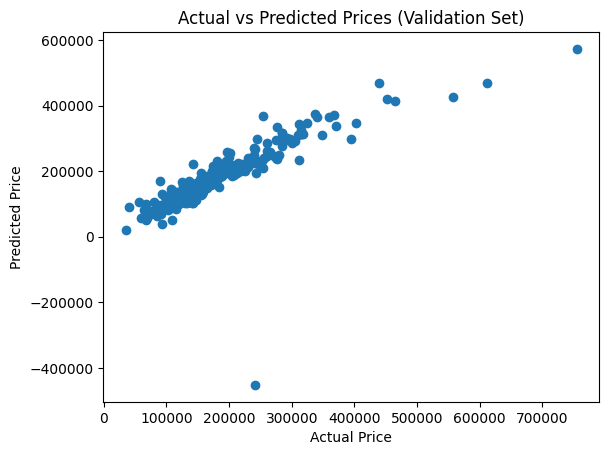

In [61]:
import matplotlib.pyplot as plt

plt.scatter(y_valid, valid_predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Validation Set)")

plt.show()

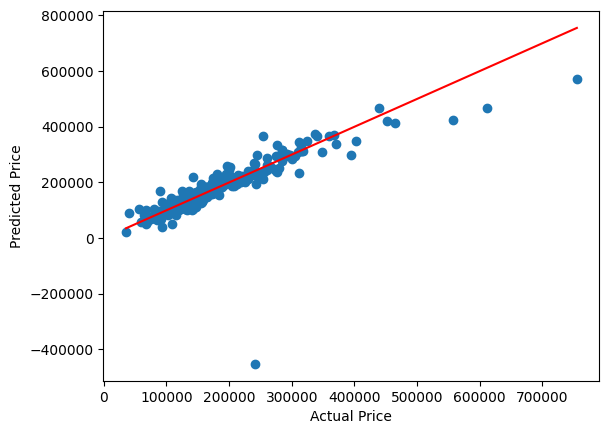

In [64]:
plt.scatter(y_valid, valid_predictions)

plt.plot(
    [y_valid.min(), y_valid.max()],
    [y_valid.min(), y_valid.max()],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

In [63]:
print(y_valid.head())
print(y_valid.dtype)

892     154500
1105    325000
413     115000
522     159000
1036    315500
Name: SalePrice, dtype: int64
int64
